In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.set_printoptions(precision=3)

In [2]:
a = [1, 2, 3, 4]
b = np.array([4, 5, 6], dtype=np.int8)

t_a = torch.tensor(a)
t_b = torch.tensor(b)
print(t_a, t_b)

tensor([1, 2, 3, 4]) tensor([4, 5, 6], dtype=torch.int8)


In [ ]:
rand_tensor = torch.rand(3, 2)
rand_tensor

tensor([[0.1049, 0.6425],
        [0.8773, 0.2829],
        [0.9625, 0.6754]])

In [4]:
t_tr = torch.transpose(rand_tensor, 0, 1)
print(f"{rand_tensor.shape} --> {t_tr.shape}")

torch.Size([3, 2]) --> torch.Size([2, 3])


#### Split, stack and concatenate tensors

In [ ]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)
t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [ ]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


---
### Building input pipelines in PyTorch

In [19]:
from torch.utils.data import DataLoader, TensorDataset

t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [9]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)
for i, batch in enumerate(data_loader, 1):
    print(f"Batch {i}: ", batch)

Batch 1:  tensor([0., 1., 2.])
Batch 2:  tensor([3., 4., 5.])


---
### Fetching available datasets from the torchvision.datasets library

In [14]:
import torchvision

image_path = "./"
celeba_dataset = torchvision.datasets.CelebA(
    image_path, split="train", target_type="attr", download=False
)

In [15]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x7F6CD0904200>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


In [16]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

---
## Building a linear regression model

In [17]:
import matplotlib.pyplot as plt

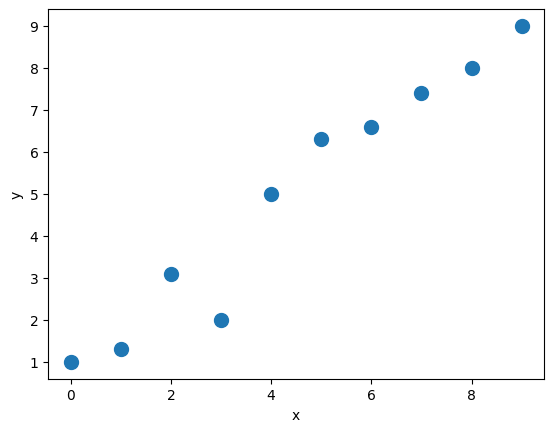

In [ ]:
X_train = np.arange(10, dtype="float").reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0], dtype="float32")

plt.plot(X_train, y_train, "o", markersize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [20]:
# Standardize
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train)

train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [26]:
torch.manual_seed(1)
weight = torch.randn(1).float()
weight.requires_grad_().float()

bias = torch.zeros(1, requires_grad=True)


def model(xb):
    return xb @ weight + bias


def loss_fn(input, target):
    return (input - target).pow(2).mean()

In [32]:
lr = 0.001
epochs = 200
log_epochs = 10

for e in range(epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.float())
        loss = loss_fn(pred, y_batch)
        loss.backward()
        with torch.no_grad():
            weight -= weight.grad * lr
            bias -= bias.grad * lr
            weight.grad.zero_()
            bias.grad.zero_()
    if e % log_epochs == 0:
        print(f"Epoch {e} Loss {loss.item():.4f}")

Epoch 0 Loss 0.0713
Epoch 10 Loss 0.0738
Epoch 20 Loss 0.0739
Epoch 30 Loss 0.0057
Epoch 40 Loss 2.4342
Epoch 50 Loss 2.4343
Epoch 60 Loss 0.1396
Epoch 70 Loss 0.0446
Epoch 80 Loss 0.2526
Epoch 90 Loss 0.7412
Epoch 100 Loss 0.0743
Epoch 110 Loss 0.0447
Epoch 120 Loss 0.2379
Epoch 130 Loss 0.0742
Epoch 140 Loss 0.7408
Epoch 150 Loss 2.4344
Epoch 160 Loss 0.0449
Epoch 170 Loss 0.0449
Epoch 180 Loss 0.1394
Epoch 190 Loss 0.0726


Final Parameters: 2.706812858581543 4.9696855545043945


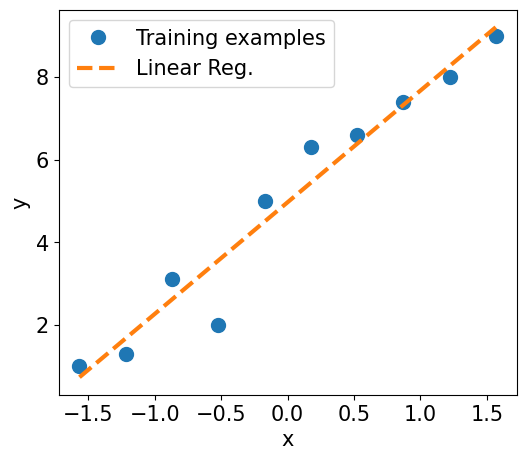

In [33]:
print("Final Parameters:", weight.item(), bias.item())

X_test = np.linspace(0, 9, num=100, dtype="float32").reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, "o", markersize=10)
plt.plot(X_test_norm, y_pred, "--", lw=3)
plt.legend(["Training examples", "Linear Reg."], fontsize=15)
ax.set_xlabel("x", size=15)
ax.set_ylabel("y", size=15)
ax.tick_params(axis="both", which="major", labelsize=15)


plt.show()

---
### Model training via the torch.nn and torch.optim modules

In [ ]:
loss_fn = nn.MSELoss(reduction="mean")
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [38]:
for e in range(epochs):
    for x_batch, y_batch in train_dl:
        # 1. generate predictions
        pred = model(x_batch.float())[:, 0]
        # 2. calculate loss
        loss = loss_fn(pred, y_batch)
        # 3. compute gradients
        loss.backward()
        # 4. update params using gradients
        optimizer.step()
        # 5. reset the gradients to zero
        optimizer.zero_grad()

    if e % log_epochs == 0:
        print(f"Epoch {e} Loss {loss.item():.4f}")

Epoch 0 Loss 0.2535
Epoch 10 Loss 0.0058
Epoch 20 Loss 0.0441
Epoch 30 Loss 0.1396
Epoch 40 Loss 0.0057
Epoch 50 Loss 0.0740
Epoch 60 Loss 0.0446
Epoch 70 Loss 0.0447
Epoch 80 Loss 0.0447
Epoch 90 Loss 0.2378
Epoch 100 Loss 0.0056
Epoch 110 Loss 2.4345
Epoch 120 Loss 0.0449
Epoch 130 Loss 0.7407
Epoch 140 Loss 0.0727
Epoch 150 Loss 0.2378
Epoch 160 Loss 0.7407
Epoch 170 Loss 0.0726
Epoch 180 Loss 2.4344
Epoch 190 Loss 0.7408


In [ ]:
print("Final Parameters:", model.weight.item(), model.bias.item())

Final Parameters: 2.7066264152526855 4.969849109649658


---
### Building a multilayer perceptron for classifying flowers in the `Iris dataset`

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

iris = load_iris()
X = iris["data"]
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1.0 / 3, random_state=1
)

In [5]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)

train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [8]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size) -> None:
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)
        return x

In [9]:
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
model = Model(input_size, hidden_size, output_size)

In [10]:
lr = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [11]:
epochs = 100
loss_hist = [0] * epochs
acc_hist = [0] * epochs
for e in range(epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_hist[e] += loss.item() * y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        acc_hist[e] += is_correct.mean()
    loss_hist[e] /= len(train_dl.dataset)  # type: ignore
    acc_hist[e] /= len(train_dl.dataset)  # type: ignore

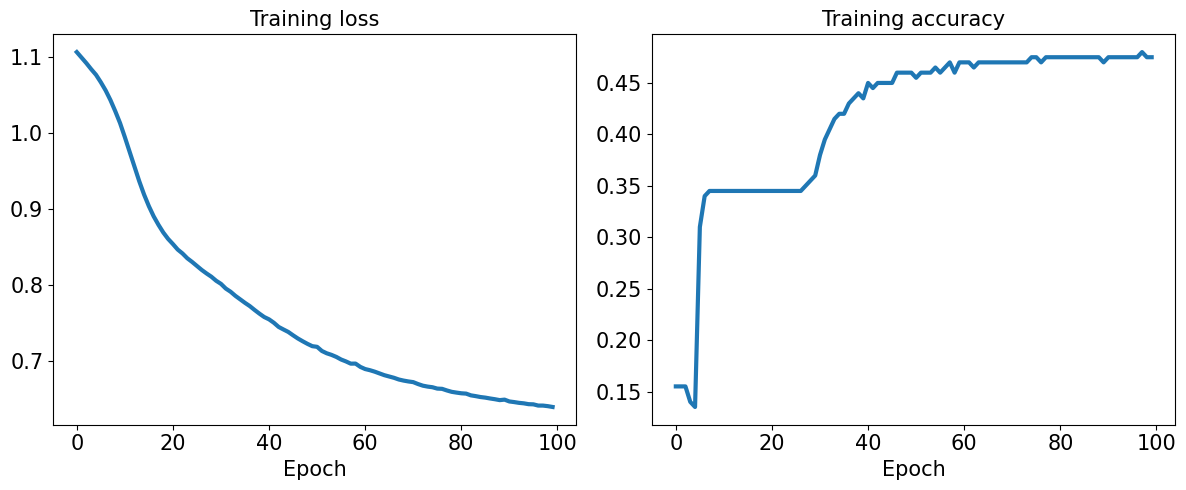

In [14]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title("Training loss", size=15)
ax.set_xlabel("Epoch", size=15)
ax.tick_params(axis="both", which="major", labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(acc_hist, lw=3)
ax.set_title("Training accuracy", size=15)
ax.set_xlabel("Epoch", size=15)
ax.tick_params(axis="both", which="major", labelsize=15)
plt.tight_layout()
plt.show()

In [15]:
# Evaluating the trained model on the test dataset
X_test_norm = (X_test - np.mean(X_test)) / np.std(X_test)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test)

pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()

print(f"Test Acc: {accuracy:.4f}")

Test Acc: 0.9800


#### Saving and relaoding the trained model

In [18]:
path = "iris_classifier.pt"
torch.save(model.state_dict(), path)

In [19]:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

<All keys matched successfully>

---